# Build a model

Are the signals from `pbs-1`, `pbs-2`, and `pbs-3` sufficiently discrimatory of human breast cancer?


## 0. Initializations

In [1]:
## 0. Initializations
# -- imports --
import anndata as ad
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns

import random

from collections import defaultdict

from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from statistics import median

from signals_in_the_noise.analysis.noise_phenotypes import classify_noise_subtypes
from signals_in_the_noise.preprocessing.gse161529 import GSE161529

In [2]:
# -- datasets --
gse = GSE161529()

## 1. Preprocessing Data

1. Subset data to samples that have a potential biological signal.
2. Determine the distribution of number of samples per subject - use to downsample for parity.
3. Determine the distribution of number of cells per subject - use to downsample for parity

In [3]:
from signals_in_the_noise.analysis.noise_phenotypes import PbsThresholds, Thresholds

pbs_1_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=0.85, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=0.3, q_high=None, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=0.3, q_high=None, q_mod_low=None, q_mod_high=None),
)
pbs_2_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=0.25, q_high=None, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=0.3, q_high=None, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.45, q_mod_high=0.85),
)
pbs_3_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=None, q_mod_low=0.3, q_mod_high=0.65),
    log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.5, q_mod_high=0.85),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=0.95, q_mod_low=None, q_mod_high=None),
)
# pbs_1_thresholds = PbsThresholds(
#     pct_counts_mt=Thresholds(q_low=None, q_high=0.9, q_mod_low=None, q_mod_high=None),
#     log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.1, q_mod_high=0.25),
#     log1p_n_genes_by_counts=Thresholds(q_low=0.25, q_high=None, q_mod_low=None, q_mod_high=None),
# )
# pbs_2_thresholds = PbsThresholds(
#     pct_counts_mt=Thresholds(q_low=0.15, q_high=None, q_mod_low=None, q_mod_high=None),
#     log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.1, q_mod_high=0.25),
#     log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.40, q_mod_high=0.65),
# )
# pbs_3_thresholds = PbsThresholds(
#     pct_counts_mt=Thresholds(q_low=None, q_high=None, q_mod_low=0.25, q_mod_high=0.55),
#     log1p_total_counts=Thresholds(q_low=None, q_high=0.45, q_mod_low=None, q_mod_high=None),
#     log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=0.7, q_mod_low=None, q_mod_high=None),
# )

In [4]:
# -- subset data --
subtype_to_adata = defaultdict(dict)
choices = ["pbs-1", "pbs-2", "pbs-3"]
for adata in gse.objects.values():
    if adata.uns['cell_population'] != 'Total':
        continue
    adata_noise = adata[adata.obs["is_noise"] == 1].copy()
    classify_noise_subtypes(adata_noise, pbs_thresholds={
        "pbs-1": pbs_1_thresholds,
        "pbs-2": pbs_2_thresholds,
        "pbs-3": pbs_3_thresholds,
})
#     classify_noise_subtypes(adata_noise)
    conditions = [
        adata_noise.obs["pbs-1"] == 1,
        adata_noise.obs["pbs-2"] == 1,
        adata_noise.obs["pbs-3"] == 1,
    ]
    adata_noise.obs["pbs"] = np.select(conditions, choices, default="none")
    adata_pbs_only = adata_noise[adata_noise.obs["pbs"] != "none"]
    subtype_to_adata[adata_pbs_only.uns['cancer_type']].update({
        adata_pbs_only.uns['title'] : adata_pbs_only
    })

In [5]:
subtype_to_adata.keys()

dict_keys(['Normal', 'BRCA1 pre-neoplastic', 'Triple negative tumour', 'Triple negative BRCA1 tumour', 'HER2+ tumour', 'PR+ tumour', 'ER+ tumour'])

In [6]:
def print_data_stats(adata_collection):
    results = []
    for subtype, adatas in adata_collection.items():
        num_subjects = len(adatas)
        num_samples = [adata.n_obs for adata in adatas.values()]
        print(f"{subtype} - {num_samples}")
        results.append((subtype, num_subjects, min(num_samples), median(num_samples)))
    
    return pd.DataFrame(results, columns=['Cancer sub-type', '# Subjects', 'Min # Samples', 'Median # Samples'])

print_data_stats(subtype_to_adata)

Normal - [310, 405, 1081, 84, 195, 248, 199, 479, 588, 242, 557, 246, 493]
BRCA1 pre-neoplastic - [311, 544, 538, 415]
Triple negative tumour - [499, 381, 94, 185]
Triple negative BRCA1 tumour - [204, 413, 1526, 2146]
HER2+ tumour - [345, 2055, 354, 84, 944, 5005]
PR+ tumour - [287]
ER+ tumour - [1726, 1858, 1674, 660, 194, 526, 1449, 484, 799, 340, 311, 795, 833, 261, 3775, 1049, 3594, 126]


,Cancer sub-type,# Subjects,Min # Samples,Median # Samples
0,Normal,13,84,310.0
1,BRCA1 pre-neoplastic,4,311,476.5
2,Triple negative tumour,4,94,283.0
3,Triple negative BRCA1 tumour,4,204,969.5
4,HER2+ tumour,6,84,649.0
5,PR+ tumour,1,287,287.0
6,ER+ tumour,18,126,797.0


### 1.a. Decisions

1. Exclude cancer sub-type `PR+ tumour` because there is only a single subject in the dataset.
2. Downsample subjects to `3` with a minimum of `50` samples.

### 1.b. Further subset data

Produces a dataset with the decisions.

In [7]:
def subset_data_for_modeling(require_min_subject=True, require_min_samples=True):
    results = {}
    for subtype, adatas in subtype_to_adata.items():
        if require_min_subject and subtype == 'PR+ tumour':
            # only has one subject, exclude
            continue
        valid_subjects_to_adata = defaultdict(dict)
        for adata in adatas.values():
            if require_min_samples and adata.n_obs < 50:
                # exclude subjects with fewer than 50 samples
                continue
            valid_subjects_to_adata.update({
                adata.uns['title']: adata,
            })
        results[subtype] = valid_subjects_to_adata
    return results
valid_adatas = subset_data_for_modeling()

In [8]:
print_data_stats(valid_adatas)

Normal - [310, 405, 1081, 84, 195, 248, 199, 479, 588, 242, 557, 246, 493]
BRCA1 pre-neoplastic - [311, 544, 538, 415]
Triple negative tumour - [499, 381, 94, 185]
Triple negative BRCA1 tumour - [204, 413, 1526, 2146]
HER2+ tumour - [345, 2055, 354, 84, 944, 5005]
ER+ tumour - [1726, 1858, 1674, 660, 194, 526, 1449, 484, 799, 340, 311, 795, 833, 261, 3775, 1049, 3594, 126]


,Cancer sub-type,# Subjects,Min # Samples,Median # Samples
0,Normal,13,84,310.0
1,BRCA1 pre-neoplastic,4,311,476.5
2,Triple negative tumour,4,94,283.0
3,Triple negative BRCA1 tumour,4,204,969.5
4,HER2+ tumour,6,84,649.0
5,ER+ tumour,18,126,797.0


### 1.3. Utility to Generate Dataset for Modeling

Creates a list of dataframe from the AnnDatas that represents all cancer sub-types (except for `PR+ tumour`), with the following characteristics:

1. `3` subjects per sub-type, `6` sub-types = `18` total subjects
2. `1` dataframe per subject
3. Columns
   1. `has_cancer`
   2. `cancer_type`
   3. `cell_population`
   4. `menopause_status`
   5. `pbs-1`
   6. `pbs-2`
   7. `pbs-3`

Separating the subjects to a row will simplify using the leave-one-out strategy.

In [9]:
def generate_dataframe_for_modeling(adata, *, downsample=True):
    results = []
    for adatas in adata.values():
        if downsample:
            subjects = np.random.choice(list(adatas.keys()), 3)
        else:
            subjects = adatas.keys()

        for subject in subjects:
            adata = adatas[subject]
            df = pd.DataFrame({
                'pbs-1': adata.obs['pbs-1'].astype(int),
                'pbs-2': adata.obs['pbs-2'].astype(int),
                'pbs-3': adata.obs['pbs-3'].astype(int),
            })
            df['has_cancer'] = (adata.uns['cancer_type'] != 'Normal')
            df['cancer_type'] = str(adata.uns['cancer_type'])
            df['cell_population'] = str(adata.uns['cell_population'])
            df['menopause_status'] = str(adata.uns['menopause_status'])
            
            results.append(df)
    return results

In [10]:
generate_dataframe_for_modeling(adata=valid_adatas)[0]

,pbs-1,pbs-2,pbs-3,has_cancer,cancer_type,cell_population,menopause_status
AAACGCTCATCGCTGG-1,1,1,0,False,Normal,Total,Post
AAACGCTTCTAGACCA-1,1,0,0,False,Normal,Total,Post
AAAGAACAGCCTGAGA-1,1,0,0,False,Normal,Total,Post
AAAGAACGTTCGAGCC-1,1,0,0,False,Normal,Total,Post
AAAGAACGTTGGGTTT-1,1,1,0,False,Normal,Total,Post
...,...,...,...,...,...,...,...
TTTATGCCAGAAGCTG-1,1,0,0,False,Normal,Total,Post
TTTATGCGTGAATATG-1,1,0,0,False,Normal,Total,Post
TTTCGATTCGTAGGAG-1,1,0,0,False,Normal,Total,Post
TTTGGTTGTGAGTCAG-1,1,0,0,False,Normal,Total,Post


## 2. Build the classifier

In [11]:
def logistic_regression_loo_classifier(dfs, *, by_subjects=True, as_dict=False, model=None, target='cancer_type'):
    loo = LeaveOneOut()
    y_true, y_pred = [], []
    
    for train_idx, test_idx in loo.split(dfs):
        train_df = pd.concat([dfs[i] for i in train_idx])
        # there will only ever be one in the test
        test_df = dfs[test_idx[0]]
    
        X_train = train_df[['pbs-1', 'pbs-2', 'pbs-3']].values
        y_train = train_df[target].values
    
        X_test = test_df[['pbs-1', 'pbs-2', 'pbs-3']].values
        y_test = test_df[target].values

        if not model:
            model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
    
        if by_subjects:
            counts = np.unique(model.predict(X_test), return_counts=True)
            # return the majority vote for the subject
            y_pred.append(counts[0][np.argmax(counts[1])])
            y_true.append(test_df[target].iloc[0])
        else:
            y_pred.extend(model.predict(X_test))
            y_true.extend(y_test)
    
    return classification_report(y_true, y_pred, output_dict=as_dict)

### 2.1. Explore other models

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import warnings
from sklearn.exceptions import UndefinedMetricWarning

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=3, weights='distance'),
    'Naive Bayes': GaussianNB()
}

### 2.2. Model ANY cancer

#### 2.3.1 Need to downsample to proceed

The data is not balanced in several ways:
- Subjects skew to having cancer
- Sample count per subject varies

To address this, build several models for different views that are more balanced:
- Normal vs Abnormal
  - Abnormal can be any combination of cancer subjects. For example, group cancer by comparable subject count.
- Subset subjects to get a balanced 

In [13]:
dfs = generate_dataframe_for_modeling(adata=valid_adatas, downsample=False)

In [14]:
dfs_cancer = []
dfs_normal = []

for df in dfs:
    if df['cancer_type'].unique()[0] == 'Normal':
        dfs_normal.append(df)
    else:
        dfs_cancer.append(df)

In [15]:
def get_balanced_dataset(minority_dfs, majority_dfs, num_minority_subjects=6):
    # select the normal subjects first, its the smaller number of total subjects
    some_minority = random.sample(minority_dfs, k=min(num_minority_subjects, len(minority_dfs)))
    # total number of cells (samples) to use for downsampling the abnormal (cancer) subjects
    num_minority_cells = sum([df.count().unique()[0] for df in some_minority])

    majority_pool = majority_dfs.copy()
    some_majority = []
    num_majority_cells = 0
    # iterate over cancer subjects
    for _ in majority_dfs:
        major = majority_pool.pop(random.randrange(len(majority_pool)))
        major_count = major.count().unique()[0]
        if major_count > num_minority_cells:
            continue
        some_majority.append(major)
        num_majority_cells += major_count
        if num_majority_cells >= num_minority_cells:
            break

    # print(num_majority_cells, num_minority_cells)
    return some_minority, some_majority
    
balanced_dfs_normal, balanced_dfs_cancer = get_balanced_dataset(dfs_normal, dfs_cancer)   

In [16]:
def report_has_cancer(minority, majority):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
        n_runs = 100
        model_avg_report = {}
        for model_name, model in models.items():
            reports = []
            for run in range(n_runs):
                _balanced_dfs_normal, _dfs = get_balanced_dataset(minority, majority)
                _dfs.extend(_balanced_dfs_normal)
                
                report = logistic_regression_loo_classifier(_dfs, by_subjects=False, as_dict=True, model=model, target="has_cancer")
                reports.append(pd.DataFrame(report).T)
        
            _avg_report = pd.concat(reports).groupby(level=0).mean()
        
            print(f"{'='*25}")
            print(f"Model: {model_name}")
            print(f"{'-'*25}")
            print(f"Mean: {_avg_report}")
            print()
            model_avg_report[model_name] = _avg_report
        return model_avg_report

report_has_cancer(dfs_normal, dfs_cancer)

Model: Logistic Regression
-------------------------
Mean:               precision    recall  f1-score     support
False          0.473398  0.673958  0.552247  2381.95000
True           0.582121  0.374245  0.448669  2889.76000
accuracy       0.510790  0.510790  0.510790     0.51079
macro avg      0.527759  0.524101  0.500458  5271.71000
weighted avg   0.535214  0.510790  0.497171  5271.71000

Model: Decision Tree
-------------------------
Mean:               precision    recall  f1-score     support
False          0.459785  0.622825  0.524207  2363.20000
True           0.569064  0.403011  0.463589  2872.70000
accuracy       0.502440  0.502440  0.502440     0.50244
macro avg      0.514425  0.512918  0.493898  5235.90000
weighted avg   0.522374  0.502440  0.492404  5235.90000

Model: KNN
-------------------------
Mean:               precision    recall  f1-score      support
False          0.034122  0.000117  0.000224  2404.140000
True           0.548573  0.997949  0.707123  2962.450000


{'Logistic Regression':               precision    recall  f1-score     support
 False          0.473398  0.673958  0.552247  2381.95000
 True           0.582121  0.374245  0.448669  2889.76000
 accuracy       0.510790  0.510790  0.510790     0.51079
 macro avg      0.527759  0.524101  0.500458  5271.71000
 weighted avg   0.535214  0.510790  0.497171  5271.71000,
 'Decision Tree':               precision    recall  f1-score     support
 False          0.459785  0.622825  0.524207  2363.20000
 True           0.569064  0.403011  0.463589  2872.70000
 accuracy       0.502440  0.502440  0.502440     0.50244
 macro avg      0.514425  0.512918  0.493898  5235.90000
 weighted avg   0.522374  0.502440  0.492404  5235.90000,
 'KNN':               precision    recall  f1-score      support
 False          0.034122  0.000117  0.000224  2404.140000
 True           0.548573  0.997949  0.707123  2962.450000
 accuracy       0.548041  0.548041  0.548041     0.548041
 macro avg      0.291348  0.499033 

In [17]:
def report_cancer_sub_types(minority, majority):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
        n_runs = 100
        model_avg_report = {}
        for model_name, model in models.items():
            reports = []
            for run in range(n_runs):
                _balanced_dfs_normal, _dfs = get_balanced_dataset(minority, majority)
                _dfs.extend(_balanced_dfs_normal)
                
                report = logistic_regression_loo_classifier(_dfs, by_subjects=False, as_dict=True, model=model)
                reports.append(pd.DataFrame(report).T)
        
            _avg_report = pd.concat(reports).groupby(level=0).mean()
        
            print(f"{'='*25}")
            print(f"Model: {model_name}")
            print(f"{'-'*25}")
            print(f"Mean: {_avg_report}")
            print()
            model_avg_report[model_name] = _avg_report
        return model_avg_report

report_cancer_sub_types(dfs_normal, dfs_cancer)

Model: Logistic Regression
-------------------------
Mean:                               precision    recall  f1-score      support
BRCA1 pre-neoplastic           0.058623  0.048972  0.049830   578.589744
ER+ tumour                     0.319130  0.150800  0.193004  1821.967033
HER2+ tumour                   0.056286  0.040515  0.037104   921.722222
Normal                         0.400075  0.389975  0.368725  2395.260000
Triple negative BRCA1 tumour   0.062576  0.046895  0.049067  1156.476190
Triple negative tumour         0.047072  0.112193  0.049374   357.195122
accuracy                       0.249634  0.249634  0.249634     0.249634
macro avg                      0.233300  0.193993  0.189786  5408.800000
weighted avg                   0.325331  0.249634  0.255704  5408.800000

Model: Decision Tree
-------------------------
Mean:                               precision    recall  f1-score      support
BRCA1 pre-neoplastic           0.069093  0.051686  0.056437   531.695652
ER+ tumour 

{'Logistic Regression':                               precision    recall  f1-score      support
 BRCA1 pre-neoplastic           0.058623  0.048972  0.049830   578.589744
 ER+ tumour                     0.319130  0.150800  0.193004  1821.967033
 HER2+ tumour                   0.056286  0.040515  0.037104   921.722222
 Normal                         0.400075  0.389975  0.368725  2395.260000
 Triple negative BRCA1 tumour   0.062576  0.046895  0.049067  1156.476190
 Triple negative tumour         0.047072  0.112193  0.049374   357.195122
 accuracy                       0.249634  0.249634  0.249634     0.249634
 macro avg                      0.233300  0.193993  0.189786  5408.800000
 weighted avg                   0.325331  0.249634  0.255704  5408.800000,
 'Decision Tree':                               precision    recall  f1-score      support
 BRCA1 pre-neoplastic           0.069093  0.051686  0.056437   531.695652
 ER+ tumour                     0.368098  0.174172  0.212968  1844.2111

In [18]:
targets = ['ER+ tumour',]
dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
avg_reports = report_cancer_sub_types(dfs_normal, dfs_target_cancer)

Model: Logistic Regression
-------------------------
Mean:               precision    recall  f1-score      support
ER+ tumour     0.599256  0.354389  0.441522  2852.280000
Normal         0.470959  0.706862  0.563250  2301.170000
accuracy       0.512826  0.512826  0.512826     0.512826
macro avg      0.535107  0.530625  0.502386  5153.450000
weighted avg   0.544468  0.512826  0.497747  5153.450000

Model: Decision Tree
-------------------------
Mean:               precision    recall  f1-score      support
ER+ tumour     0.593653  0.372071  0.454352  2909.230000
Normal         0.460067  0.674499  0.545104  2295.340000
accuracy       0.506423  0.506423  0.506423     0.506423
macro avg      0.526860  0.523285  0.499728  5204.570000
weighted avg   0.537073  0.506423  0.496096  5204.570000

Model: KNN
-------------------------
Mean:               precision    recall  f1-score      support
ER+ tumour     0.551905  0.998751  0.710250  3009.000000
Normal         0.055119  0.000131  0.000262  

In [19]:
# targets = ['HER2+ tumour', 'Triple negative tumour', 'Triple negative BRCA1 tumour']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [20]:
# targets = ['Triple negative tumour', 'Triple negative BRCA1 tumour']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [21]:
# targets = ['HER2+ tumour']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [22]:
# targets = ['BRCA1 pre-neoplastic']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [23]:
def figure_for_poster(avg_report, minority_label="True", majority_label="False", small=False):
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import numpy as np
    
    # ── DATA from avg_report ─────────────────────────────────────────────────────
    support_false   = avg_report.loc[majority_label,     "support"]
    support_true    = avg_report.loc[minority_label,      "support"]
    recall_false    = avg_report.loc[majority_label,     "recall"]
    recall_true     = avg_report.loc[minority_label,      "recall"]
    precision_false = avg_report.loc[majority_label,     "precision"]
    precision_true  = avg_report.loc[minority_label,      "precision"]
    f1_false        = avg_report.loc[majority_label,     "f1-score"]
    f1_true         = avg_report.loc[minority_label,      "f1-score"]
    accuracy        = avg_report.loc["accuracy",  "f1-score"]
    macro_f1        = avg_report.loc["macro avg", "f1-score"]
    
    tn = round(support_false * recall_false)
    fp = round(support_false * (1 - recall_false))
    fn = round(support_true  * (1 - recall_true))
    tp = round(support_true  * recall_true)
    
    cm      = np.array([[tn, fp], [fn, tp]])
    support = [support_false, support_true]
    blue    = "#0072B2"
    orange  = "#D55E00"
    
    # ── FIGURE ───────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(8, 5))
    
    ax_cm     = fig.add_axes([0.05, 0.10, 0.50, 0.80])

    if small:
        font_sizes = [26, 20, 20]
    else:
        font_sizes = [32, 26, 20]
    
    # ── CONFUSION MATRIX ─────────────────────────────────────────────────────────
    if small:
        classes = [f"{minority_label}", f"{majority_label}"]
    else:
        classes = [f"{minority_label}\n(no cancer)", f"{majority_label}\n(cancer)"]
    
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            pct = val / support[i] if support[i] > 0 else 0
     
            if i == j:
                color = blue
                alpha = 0.15 + pct * 0.75
            else:
                color = orange
                alpha = 0.10 + pct * 0.70

            if small:
                rect = patches.FancyBboxPatch(
                    (j + 0.08, 1 - i + 0.08), 0.84, 0.84,
                    boxstyle="round,pad=0.02",
                    facecolor=color, alpha=max(alpha, 0.08),
                    linewidth=0
                )
            else:
                rect = patches.FancyBboxPatch(
                    (j + 0.04, 1 - i + 0.04), 0.92, 0.92,
                    boxstyle="round,pad=0.02",
                    facecolor=color, alpha=max(alpha, 0.08),
                    linewidth=0
                )
            ax_cm.add_patch(rect)
     
            text_color = "#00274C"
            if small:
                ax_cm.text(j + 0.5, 1 - i + 0.60, f"{int(val):,}",
                           ha="center", va="center",
                           fontsize=font_sizes[0], fontweight="500", color=text_color)
                ax_cm.text(j + 0.5, 1 - i + 0.35, f"{pct:.1%}",
                           ha="center", va="center",
                           fontsize=font_sizes[1], color=text_color, alpha=0.85)
            else:
                ax_cm.text(j + 0.5, 1 - i + 0.60, f"{int(val):,}",
                           ha="center", va="center",
                           fontsize=font_sizes[0], fontweight="500", color=text_color)
                ax_cm.text(j + 0.5, 1 - i + 0.28, f"{pct:.1%}",
                           ha="center", va="center",
                           fontsize=font_sizes[1], color=text_color, alpha=0.85)
     
    ax_cm.set_xticks([0.5, 1.5])
    ax_cm.set_xticklabels(classes, fontsize=font_sizes[2], color="#00274C")
    ax_cm.set_yticks([0.5, 1.5])
    ax_cm.set_yticklabels(classes[::-1], fontsize=font_sizes[2])
    ax_cm.set_xlim(0, 2)
    ax_cm.set_ylim(0, 2)
    ax_cm.set_xlabel("predicted label", fontsize=font_sizes[2])
    ax_cm.set_ylabel("true label", fontsize=font_sizes[2])
    ax_cm.spines[:].set_visible(False)
    ax_cm.tick_params(length=0)
    
    # from matplotlib.patches import Patch
    # legend_elements = [
    #     Patch(facecolor=blue,   alpha=0.8, label="correct"),
    #     Patch(facecolor=orange, alpha=0.8, label="misclassified"),
    # ]
    # ax_metric.legend(handles=legend_elements,
    #                  loc="lower right",
    #                  bbox_to_anchor=(1, -0.01),
    #                  frameon=False, fontsize=8,
    #                  ncol=1, handlelength=1)
    
    # ── METRICS PANEL ────────────────────────────────────────────────────────────
    # ax_metric.axis("off")
    
    # ax_metric.text(0, 1.00, "accuracy",       transform=ax_metric.transAxes,
    #                fontsize=9, color="gray")
    # ax_metric.text(0, 0.92, f"{accuracy:.1%}", transform=ax_metric.transAxes,
    #                fontsize=20, fontweight="500")
    # ax_metric.text(0, 0.82, "macro F1",       transform=ax_metric.transAxes,
    #                fontsize=9, color="gray")
    # ax_metric.text(0, 0.74, f"{macro_f1:.3f}", transform=ax_metric.transAxes,
    #                fontsize=20, fontweight="500")
    
    # ax_metric.axhline(y=0.70, xmin=0, xmax=1,
    #                   color="#CCCCCC", linewidth=0.5)
    
    # ax_metric.text(0, 0.66, "recall / F1 by class", transform=ax_metric.transAxes,
    #                fontsize=9, color="gray")
    
    # metrics = [
    #     ("no cancer recall", recall_false, blue),
    #     ("cancer recall",    recall_true,  orange),
    #     ("no cancer F1",     f1_false,     blue),
    #     ("cancer F1",        f1_true,      orange),
    # ]
    
    # bar_y = [0.58, 0.46, 0.31, 0.19]
    
    # for (label, val, color), y in zip(metrics, bar_y):
    #     ax_metric.text(0, y + 0.02, label, transform=ax_metric.transAxes,
    #                    fontsize=8, color="white")
    #     ax_metric.text(1, y + 0.02, f"{val*100:.2f}%", transform=ax_metric.transAxes,
    #                    fontsize=8, color="black", ha="right")
    #     ax_metric.add_patch(patches.FancyBboxPatch(
    #         (0, y), 1, 0.06,
    #         boxstyle="round,pad=0.005",
    #         transform=ax_metric.transAxes,
    #         facecolor="#EEEEEE", linewidth=0, clip_on=False
    #     ))
    #     if val > 0.001:
    #         ax_metric.add_patch(patches.FancyBboxPatch(
    #             (0, y), val, 0.06,
    #             boxstyle="round,pad=0.005",
    #             transform=ax_metric.transAxes,
    #             facecolor=color, alpha=0.8, linewidth=0, clip_on=False
    #         ))
    
    # ax_metric.axhline(y=0.14, xmin=0, xmax=1,
    #                   color="#CCCCCC", linewidth=0.5)
    
    # ax_metric.text(0, 0.08, f"no cancer  n={int(support_false):,}",
    #                transform=ax_metric.transAxes, fontsize=8, color="gray")
    # ax_metric.text(0, 0.00, f"cancer     n={int(support_true):,}",
    #                transform=ax_metric.transAxes, fontsize=8, color="gray")
    
    # plt.suptitle("Decision Tree — mean classification report", fontsize=11, y=0.97)
    plt.rcParams.update({
        'axes.labelcolor': "#00274C",
        'text.color': "#00274C",
        'xtick.labelcolor': "#00274C",
        'ytick.labelcolor': "#00274C",
    })
    if small:
        plt.savefig("../images/umsi-expo-postcard.png", dpi=300, bbox_inches="tight", transparent=True)
    else:
        plt.savefig("../images/umsi-expo-figure-4.png", dpi=300, bbox_inches="tight", transparent=True)
    plt.show()

In [24]:
avg_report = avg_reports['Decision Tree']

In [25]:
avg_report

,precision,recall,f1-score,support
ER+ tumour,0.593653,0.372071,0.454352,2909.230000
Normal,0.460067,0.674499,0.545104,2295.340000
accuracy,0.506423,0.506423,0.506423,0.506423
macro avg,0.526860,0.523285,0.499728,5204.570000
weighted avg,0.537073,0.506423,0.496096,5204.570000


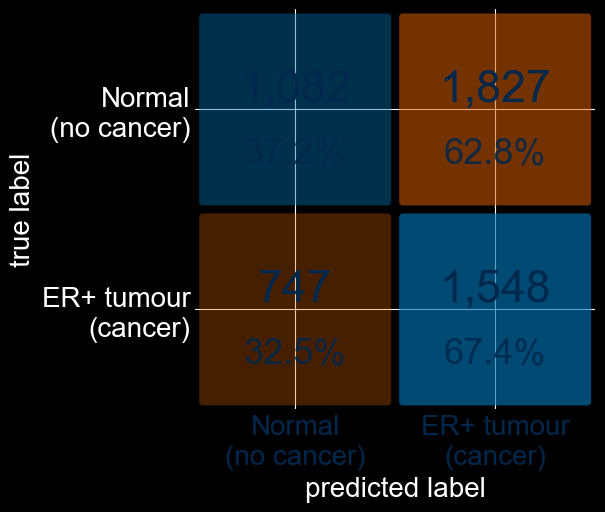

In [26]:
figure_for_poster(avg_report, "Normal", "ER+ tumour")

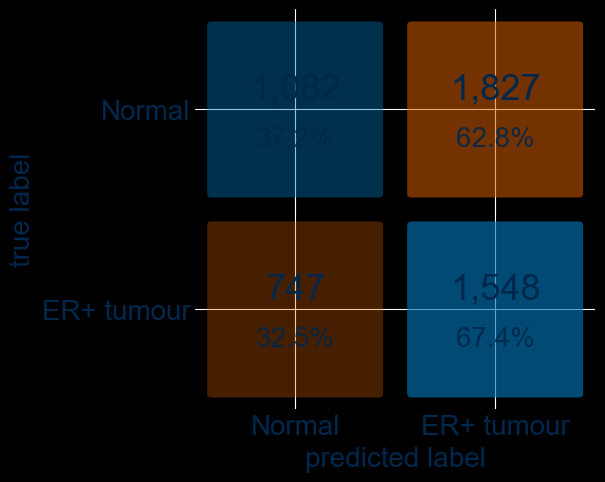

In [27]:
figure_for_poster(avg_report, "Normal", "ER+ tumour", small=True)